In [ ]:
# just put your path to the ../ dir
%cd /mnt/c/Users/louis/Documents/GitHub/Low-Dimensionnal-Model-2025

import fct_BoxModel_mu0 as fbm_mu0

import numpy as np
from scipy.optimize import fsolve, root

import xarray as xr
import pandas as pd
import matplotlib
from matplotlib import cm
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
import cv2 as cv

from matplotlib import colors

from cmcrameri import cm as cmcra



matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=128):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

lipari_cut = truncate_colormap(cmcra.lipari, minval=0.15, maxval=1.0, n=128)

/mnt/c/Users/louis/Documents/GitHub/Low-Dimensionnal-Model-2025


### Importing the datasets

In [13]:
inputs = xr.open_dataset("model_input_dataset.nc")
index_isf = inputs.Nisf.values
name_isf = inputs.name_isf.values

outputs = xr.open_dataset("model_output_dataset.nc")

q_used = np.array([0.13,0.23,0.19,0.05,0.23,0.12,0.07,0.25,0.17])*1e6 #m^3/s

### Defining the parameters

In [14]:
# Define reference properties and parameters 

#PICO parameters
# Reese 2018
gammaT = 2e-5 #m/s

#Vertical mixing
# ~Olbers & Hellmer 2010
kappa_diff = 1e-7  # m/s
kappa_conv = 1e-3 # m/s

#Polynia
g = 20

#densities
rho_i = 910 #kg/m^3

# non zero q_conv
r = 0.

### Defining plotting fuction

In [15]:
# functions to compute the bistable region size

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

def bistable_size(bistable,T_CDW_list,T_CDW_ref,Ap_list):
    idx = find_nearest(T_CDW_list,T_CDW_ref)
    bist_arg = np.where(bistable[:,idx].mask == False)[0]
    Apbmin = Ap_list[bist_arg[0]]
    Apbmax = Ap_list[bist_arg[-1]]
    delta_Ap = Apbmax-Apbmin
    return Apbmin, Apbmax, delta_Ap

In [22]:
def plot_column():

    AABW = False #Include AABW parameterisation ?
    
    Npoint = 100
    
    T_CDW_list = np.linspace(-2.1,2.1,Npoint)
    
    for k, index, name in zip(np.arange(len(index_list)),index_list,name_list):
        print(name)
    
        Ap_ref = np.mean(inputs.Ap.sel(Nisf=index).values)*2/3 # Interannual average, 2/3 factor to include summer
    
    
        stability_d = np.zeros((Npoint,Npoint))
        stability_c = np.zeros((Npoint,Npoint))
    
        melt_d = np.zeros((Npoint,Npoint))
        melt_c = np.zeros((Npoint,Npoint))
    
        sigma_d = np.zeros((Npoint,Npoint))
        sigma_c = np.zeros((Npoint,Npoint))
        
        nbox = int(inputs.Nbox.sel(Nisf=index).values)
        Ac = inputs.Ac.sel(Nisf=index).values #m^2
    
        xi_ref = np.mean(inputs.xi.sel(Nisf=index).values)/30/24/3600 * 2/3 #m/s : 2/3 factor to include summer
        y_axis = np.logspace(-1,3,Npoint)
        Ap_list = y_axis/xi_ref/rho_i *1e12/3600/24/365.25
        
        frac = inputs.frac.sel(Nisf=index).values
        depth = inputs.depth.sel(Nisf=index).values
        S_CDW_ref = np.mean(inputs.S_CDW.sel(Nisf=index).values)
    
        q_ref = q_used_list[k]
        
        guess_conv_0 = np.array([0,0,35.5,35.5])
        guess_diff_0 = np.array([0,0,35.5,35.5])
        
        for n, T_CDW in enumerate(T_CDW_list):
    
            guess_conv = guess_conv_0
            guess_diff = guess_diff_0
            
            for m, Ap in enumerate(Ap_list):

                args = (nbox, q_ref, gammaT, Ac, xi_ref, T_CDW, S_CDW_ref, Ap, kappa_diff, g, frac, depth, r)
        
                X_d, info, ier, msg = fsolve(fbm_mu0.BoxModel, guess_diff, args = args, full_output=True,)
                if ier != 1: #management of non convergence cases
                    incr = 0
                    while ier != 1 or X_d[3]<30 or X_d[1]<30:
                        X_d, info, ier, msg = fsolve(fbm_mu0.BoxModel, np.random.normal(guess_diff,0.15), args = args, full_output=True)
                        incr += 1
                        if incr == 200:
                            print('no conv, diff',m,n)
                            break
                if ier == 1:
                    guess_diff = X_d
                    if m==0:
                        guess_diff_0 = X_d 
    
                if ier==1:
                    sigma_d[m,n] = fbm_mu0.compute_Sigma(X_d)
                    stability_d[m,n] = fbm_mu0.compute_Sigma(X_d)<0
                    if stability_d[m,n]:
                        T,S,melt = fbm_mu0.PICO(X_d[1],X_d[3], nbox, q_ref, gammaT, Ac, frac, depth)
                        melt_d[m,n] = fbm_mu0.compute_m_avg(melt,frac,nbox)
                    else:
                        melt_d[m,n] = np.nan
                else:
                    stability_d[m,n] = np.nan
                    melt_d[m,n] = np.nan
                    
                
                args = (nbox, q_ref, gammaT, Ac, xi_ref, T_CDW, S_CDW_ref, Ap, kappa_conv, g, frac, depth, r)

                X_c, info, ier, msg = fsolve(fbm_mu0.BoxModel, guess_conv, args = args, full_output=True)
                if ier != 1: #management of non convergence cases
                    incr = 0
                    while ier != 1:
                        X_c, info, ier, msg = fsolve(fbm_mu0.BoxModel, np.random.normal(guess_conv,0.15), args = args, full_output=True)
                        incr += 1
                        if incr == 200:
                            print('no conv, conv',m,n)
                            break
                if ier==1:
                    guess_conv = X_c
                    if m==0:
                        guess_conv_0 = X_c
                
    
                if ier==1:
                    sigma_c[m,n] = fbm_mu0.compute_Sigma(X_c)
                    stability_c[m,n] = fbm_mu0.compute_Sigma(X_c)>0
                    if stability_c[m,n]:
                        T,S,melt = fbm_mu0.PICO(X_c[1],X_c[3], nbox, q_ref, gammaT, Ac, frac, depth)
                        melt_c[m,n] = fbm_mu0.compute_m_avg(melt,frac,nbox)
                    else:
                        melt_c[m,n] = np.nan
                else:
                    stability_c[m,n] = np.nan
                    melt_c[m,n] = np.nan
    
                
        # show monostable and bistable cases
        stability_map = np.logical_and(stability_c,stability_d)*0 + np.logical_and(stability_c,np.logical_not(stability_d))*(-1) + np.logical_and(np.logical_not(stability_c),stability_d)*1
    
        # show unstable cases 
        stability_map = np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)), stability_map)

        # Compute basal mass losses
        melt_c = melt_c*12 *rho_i*Ac /1e12 # Gt/y
        melt_d = melt_d*12 *rho_i*Ac /1e12 # Gt/y

        # Plot basal mass losses
        melt_conv = ax[k].contourf(T_CDW_list, y_axis, melt_c,cmap=lipari_cut,vmin=0,vmax=vmax, levels=levels_d)
        melt_diff = ax[k].contourf(T_CDW_list, y_axis, melt_d,cmap=lipari_cut,vmin=0,vmax=vmax, levels=levels_d)

        # Compute and plot bistable region
        bistable_zone = np.ma.masked_where(np.logical_not(np.logical_and(stability_c,stability_d)),np.logical_and(stability_c,stability_d)*0.25)
        ax[k].contourf(T_CDW_list, y_axis, bistable_zone,cmap='binary',vmin=0,vmax=1,levels=np.linspace(0,1,6))
    
        # Plot transition thresholds
        if np.max(sigma_d)>0:
            ax[k].contour(T_CDW_list,y_axis,sigma_d,colors='black',levels=0)
        if np.min(sigma_c)<0:
            ax[k].contour(T_CDW_list,y_axis,sigma_c,colors='black',levels=0,linestyles='dashed')
        
        ax[k].set_title(name)
        ax[k].set_yscale('log')
        ax[k].set_xlim((-2.1,2.1))
        ax[k].set_ylim((1e-1,1e3)) # same y-axis
        
        ax[k].set_ylabel(r'Sea-ice prod. $\Sigma$'+' '+r'$\mathrm{[Gt/y]}$')
        
        if k==kmax:
            ax[k].set_xlabel(r'$T_\mathrm{CDW}$'+' [°C]')

        # Compute and scatter plot realistic forcings
        T_CDW_series = inputs.T_CDW.sel(Nisf=index).values
        SeaIce_series = inputs.Ap.sel(Nisf=index).groupby('time.year').mean('time').values *rho_i*xi_ref *24*3600*365.25/1e12    *2/3 #2/3 factors to take summer into account
        ax[k].scatter(T_CDW_series,SeaIce_series,marker='+', c='white', zorder=2) 
        ax[k].scatter(np.mean(T_CDW_series),np.mean(SeaIce_series),facecolors='white',edgecolors='black',marker='d',s=50,linewidths=1, zorder=2) #interannual mean
    
        # compute the bistable region size
        Apbmin, Apbmax, delta_Ap = bistable_size(bistable_zone,T_CDW_list,np.mean(T_CDW_series),Ap_list)
        print(delta_Ap*rho_i*xi_ref*24*3600*365.25/1e12,'Gt/y')

        # contour plot of the convective basal mass loss
        contour_c = np.ma.masked_where(stability_map !=-1,melt_c)
        cont_c = ax[k].contour(T_CDW_list, y_axis, contour_c, levels_c, colors='whitesmoke', linewidths=1) 
        ax[k].clabel(cont_c, fontsize=8)

    # colorbar
    cbar_ax = fig.add_axes([0.13, bottom_cbar, 0.75, height_cbar])  # [left, bottom, width, height]
    cbar = fig.colorbar(melt_diff, cax=cbar_ax, orientation='horizontal',
                        label=r'Basal melt $\mathcal{M}$ [Gt/y]') 
    # Move ticks and label to the top
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')

### Small cavities

Pine Island
59.41667759396911 Gt/y
Dotson
38.16041634377964 Gt/y
Totten
59.41667759396912 Gt/y
Moscow Univ.
50.93107826079018 Gt/y


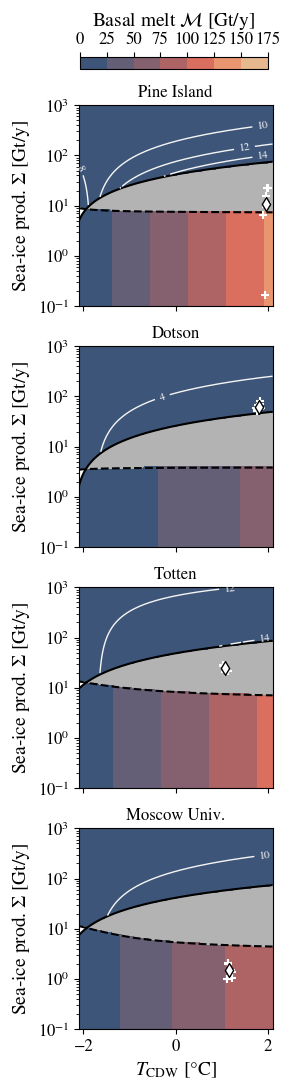

In [23]:
# Warning if computation take to much time, maybe the algotithm can't find some fixed point. Just launch it again because no convergence is tackle with a random walk exploration of the phase space
np.random.seed(0) # this seed works well here

index_list = [66,52,48,33]
name_list = ['Pine Island', 'Dotson', 'Totten', 'Moscow Univ.']
kmax = 4-1
vmax = 200 #Gt/y
levels_c = np.arange(0,20,2)
levels_d = np.arange(0,200,25)
height_cbar = 0.01
bottom_cbar = 0.91

q_used_list = np.array([0.21,0.05,0.1,0.1])*1e6 #m^3/s

fig, ax = plt.subplots(4,1,figsize=(2.5,12),sharex=True, sharey=True,)


plot_column()

plt.savefig('SI/Figures/FigureS1/FigureS1_small.pdf',format="pdf", bbox_inches = 'tight')
plt.show()

### Medium Cavities

Amery
131.36633174510337 Gt/y
Riiser-Larsen
55.896795516447405 Gt/y
Roi Baudouin
37.757550235766395 Gt/y


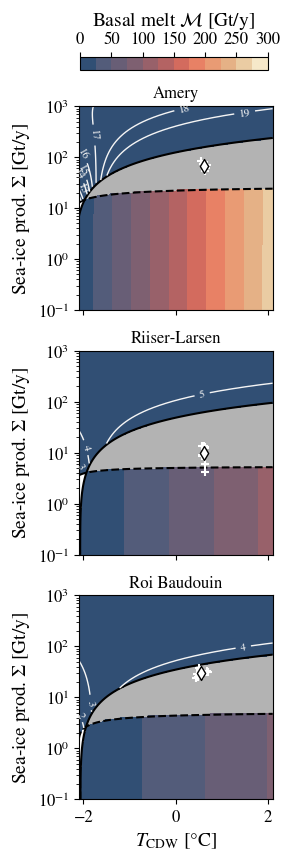

In [25]:
np.random.seed(0) # this seed works well here

index_list = [31,43,45]
name_list = ['Amery','Riiser-Larsen', 'Roi Baudouin']
kmax = 3-1
vmax = 300 #Gt/y
levels_c = np.arange(0,20,1)
levels_d = np.arange(0,301,25)
height_cbar = 0.01*3/2
bottom_cbar = 0.92

q_used_list = np.array([170000.,70000.,50000.]) #m^3/s

fig, ax = plt.subplots(3,1,figsize=(2.5,9),sharex=True, sharey=True,)


plot_column()

plt.savefig('SI/Figures/FigureS1/FigureS1_medium.pdf',format="pdf", bbox_inches = 'tight')
plt.show()

### Large Cavities

Ross
154.05425937506863 Gt/y
Filchner-Ronne
131.36633174510342 Gt/y


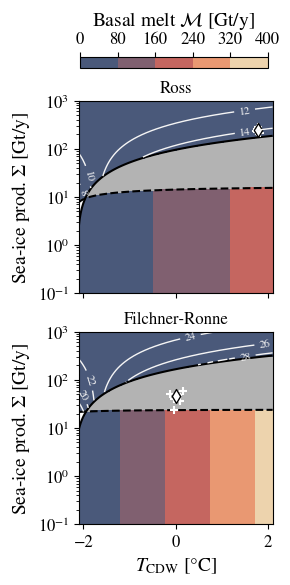

In [26]:
np.random.seed(0) # this seed works well here

index_list = [10,11]
name_list = ['Ross','Filchner-Ronne']
kmax = 2-1
vmax = 400 #Gt/y
levels_c = np.arange(0,40,2)
levels_d = np.arange(0,401,80)
height_cbar = 0.01*2
bottom_cbar = 0.94

q_used_list = np.array([130000.,220000.]) #m^3/s

fig, ax = plt.subplots(2,1,figsize=(2.5,5.5),sharex=True, sharey=True,)


plot_column()

plt.savefig('SI/Figures/FigureS1/FigureS1_large.pdf',format="pdf", bbox_inches = 'tight')
plt.show()